<a href="https://colab.research.google.com/github/Worapong7849/ThaiSpeechRecognition/blob/main/Lab03_ThaiSpeechRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 DSP Lab 03: The Machine That Listens (Speech Recognition)

ใน Lab 02 เราได้เรียนรู้การใช้ **FFT** และ **Spectrogram** เพื่อแปลงเสียงให้กลายเป็นภาพ 2 มิติกันไปแล้ว
ใน Lab นี้ เราจะนำ "ภาพ Spectrogram" เหล่านั้นมาป้อนให้ **โครงข่ายประสาทเทียม (Artificial Neural Network - ANN)** เพื่อสอนให้คอมพิวเตอร์ "ฟัง" และ "เข้าใจ" เสียงพูดของมนุษย์!

---

## 🛠️ Step 0: เตรียมเครื่องมือ (Setup)
รัน Cell ด้านล่างเพื่อนำเข้า Library ที่จำเป็น เราจะใช้ `librosa` สำหรับจัดการเสียง และ `TensorFlow/Keras` สำหรับสร้าง AI

In [2]:
import os
import time
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import Audio, display, HTML, clear_output
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Audio, display
print("✅ เครื่องมือพร้อมสำหรับการสร้าง AI!")

✅ เครื่องมือพร้อมสำหรับการสร้าง AI!


---
## 📥 Mission 1: Data Harvesting (รวบรวมข้อมูลเสียง)
AI จะฉลาดได้ต้องมีข้อมูลให้เรียนรู้ เราจะดาวน์โหลดชุดข้อมูล **Mini Speech Commands** ซึ่งประกอบด้วยไฟล์เสียงพูดสั้นๆ (1 วินาที)

In [5]:

# =========================
# 1) เคลียร์ + แตกไฟล์
# =========================
!rm -rf data/

# แตก zip จากไฟล์ที่อัปโหลด
!unzip -q -o /content/thai_speech_dataset.zip -d data/

# =========================
# 2) ตรวจโครงสร้างโฟลเดอร์
# =========================
print("📁 โครงสร้างใน data/:")
!ls data/

# auto-detect path (กันกรณีมี folder ครอบ)
if len(os.listdir('data')) == 1 and os.path.isdir(os.path.join('data', os.listdir('data')[0])):
    data_dir = pathlib.Path(os.path.join('data', os.listdir('data')[0]))
else:
    data_dir = pathlib.Path('data')

print("📌 ใช้ path:", data_dir)

# =========================
# 3) โหลด classes
# =========================
commands = np.array([
    cmd for cmd in tf.io.gfile.listdir(str(data_dir))
    if not cmd.startswith('.') and os.path.isdir(os.path.join(data_dir, cmd))
])

print("📚 Classes:", commands)
print("🔢 จำนวน =", len(commands), "คำ")

# =========================
# 4) ฟังเสียงตัวอย่าง
# =========================
label = commands[0]  # เอาคำแรก

sample_audio_path = os.path.join(
    data_dir,
    label,
    os.listdir(os.path.join(data_dir, label))[0]
)

print("🔊 กำลังเล่นคำ:", label)
display(Audio(sample_audio_path))

📁 โครงสร้างใน data/:
แก้ไฟล์
📌 ใช้ path: data/แก้ไฟล์
📚 Classes: ['เป็น' 'ดำ' 'หลับ' 'หิว']
🔢 จำนวน = 4 คำ
🔊 กำลังเล่นคำ: เป็น


---
## 🌈 Mission 2: Feature Extraction (The Mel Scale)
AI แบบ CNN เก่งเรื่องการดูรูปภาพ เราจึงต้องแปลงเสียงให้เป็นภาพ **Mel-Spectrogram**

**💡 ทบทวนความรู้จาก Slide:** หูมนุษย์รับรู้ความถี่แบบไม่เป็นเส้นตรง เรามักจะบีบความถี่เป็นแบนด์ (Mel bands) จำนวน 64 แบนด์ และเสียงพูดปกติจะมีความถี่ไม่เกิน 8,000 Hz

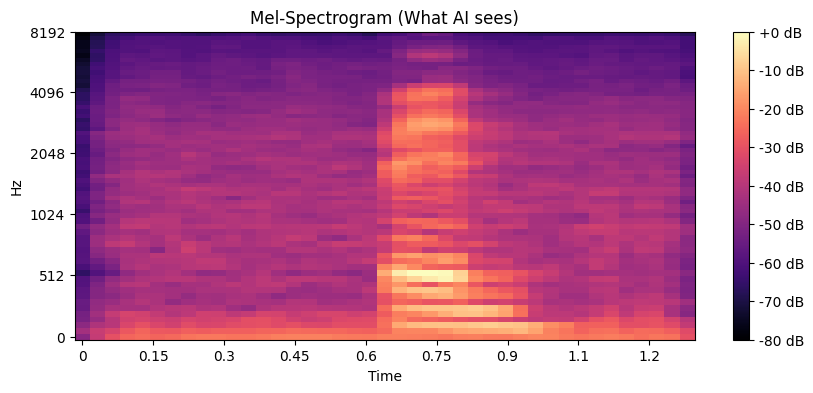

In [6]:
y, sr = librosa.load(sample_audio_path, sr=16000)

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 1: เติมพารามิเตอร์ให้ตรงกับทฤษฎีการได้ยินของมนุษย์
# ---------------------------------------------------------
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)

S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram (What AI sees)')
plt.show()

---
## 🧠 Mission 3: Building the Brain (สร้างสมอง AI)
เตรียมข้อมูลเสียงทั้งหมดและสร้างโมเดล **CNN**

**💡 ทบทวนความรู้จาก Slide:** Layer สุดท้ายของ Neural Network (Output Layer) จะต้องมีจำนวนเซลล์เท่ากับ "จำนวนคลาส" ที่เราต้องการแยกแยะ และใช้ฟังก์ชัน Softmax เพื่อแปลงเป็น % ความน่าจะเป็น

In [7]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=None,   # 🔥 เปลี่ยนตรงนี้ (จาก 64 → None)
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both'
)

label_names = np.array(train_ds.class_names)
num_classes = len(label_names)

# =========================
# แปลงเสียง → spectrogram
# =========================
def get_spectrogram(audio, label):
    # 🔥 แปลง stereo → mono
    audio = tf.reduce_mean(audio, axis=-1, keepdims=True)

    audio = tf.squeeze(audio, axis=-1)

    spectrogram = tf.signal.stft(audio, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)

    # normalize
    spectrogram = tf.math.log(spectrogram + 1e-10)

    spectrogram = tf.expand_dims(spectrogram, -1)
    return spectrogram, label

train_spectrogram_ds = train_ds.map(map_func=get_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.map(map_func=get_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)

# 🔥 เพิ่ม batch กลับมา (แต่ทำหลัง map)
train_spectrogram_ds = train_spectrogram_ds.batch(64).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.batch(64).cache().prefetch(tf.data.AUTOTUNE)

# =========================
# input shape
# =========================
for example_spectrograms, example_labels in train_spectrogram_ds.take(1):
    input_shape = example_spectrograms.shape[1:]

# =========================
# model
# =========================
model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Found 200 files belonging to 4 classes.
Using 160 files for training.
Using 40 files for validation.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,372 (1.20 MB)

 Trainable params: 314,372 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

---
## ⚔️ Mission 4: Training (กระบวนการฝึกฝน)
**💡 ทบทวนความรู้จาก Slide:** การฝึก AI ต้องทำซ้ำๆ เรียกว่า Epoch ยิ่ง Epoch เยอะ AI ยิ่งได้ทบทวนบทเรียน

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 369ms/step - accuracy: 0.9625 - loss: 0.0962 - val_accuracy: 1.0000 - val_loss: 0.0392
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.9187 - loss: 0.1826 - val_accuracy: 1.0000 - val_loss: 0.0467
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9812 - loss: 0.0678 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9812 - loss: 0.0646 - val_accuracy: 1.0000 - val_loss: 0.0115
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 1.0000 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9937 - loss: 0.0166 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 0.

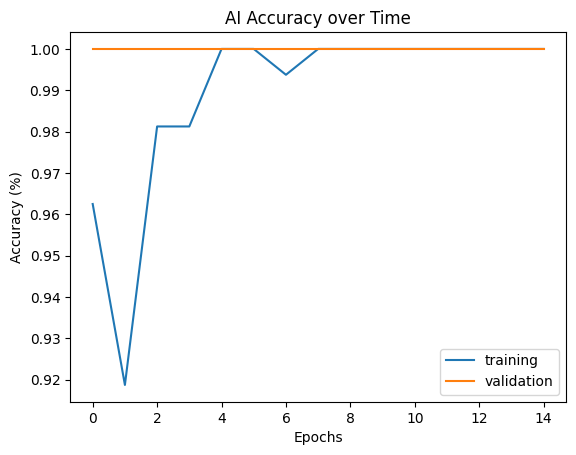

In [17]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 3: กำหนดรอบการฝึกฝน (ลองใส่สัก 10 รอบ)
# ---------------------------------------------------------
EPOCHS = 25

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(verbose=1, patience=2)],
)

metrics = history.history
plt.plot(history.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['training', 'validation'])
plt.title('AI Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

---
## 🎙️ Mission 5: The Ultimate Test (ทดสอบเสียงของคุณเอง!)
เปิดไมโครโฟน แล้วพูดคำว่า `down, go, left, right, no, yes, stop, up` มา 1 คำ

**💡 ทบทวนความรู้จาก Slide (Data Consistency):** ไฟล์เสียงตอนทดสอบ ต้องมีขนาด Data Points เท่ากับตอนเทรนเป๊ะๆ ถ้าเราใช้เวลา 1 วินาที ที่ Sampling rate 16,000 Hz แปลว่าเราต้องการข้อมูลทั้งหมดกี่จุด?


🤖 AI มั่นใจว่าคุณพูดคำว่า: 👉 [ ดำ ] 👈



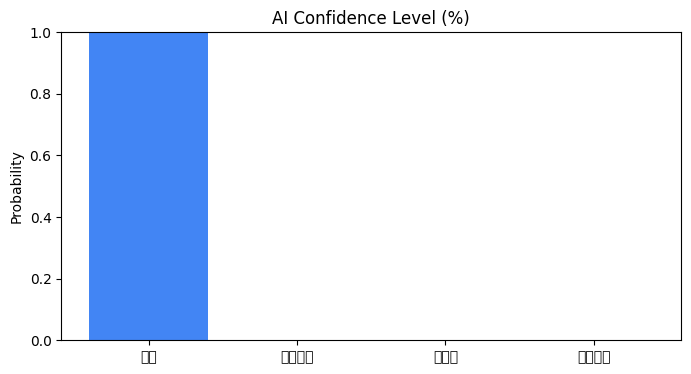

In [22]:
file_id = int(time.time())
webm_file = f'my_test_{file_id}.webm'
wav_file = f'my_test_{file_id}.wav'

AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_btn = document.createElement("BUTTON");
my_btn.style.padding = "10px 20px"; my_btn.style.fontSize = "16px"; my_btn.style.cursor = "pointer";
var t = document.createTextNode("🎤 กดเพื่อบันทึกเสียง (1 วินาที)");
my_btn.appendChild(t); my_div.appendChild(my_btn); document.body.appendChild(my_div);
var base64data = 0; var reader; var recorder, gumStream; var recordButton = my_btn;
var handleSuccess = function(stream) {
  gumStream = stream;
  recorder = new MediaRecorder(stream, { mimeType : 'audio/webm;codecs=opus' });
  recorder.ondataavailable = function(e) {
    reader = new FileReader(); reader.readAsDataURL(e.data);
    reader.onloadend = function() { base64data = reader.result; }
  };
  recorder.start(); recordButton.innerText = "🔴 กำลังบันทึก... พูดเลย!";
  setTimeout(() => { recorder.stop(); gumStream.getAudioTracks()[0].stop(); recordButton.innerText = "✅ สำเร็จ! กำลังส่งให้ AI..."; }, 1500);
};
recordButton.onclick = function() { navigator.mediaDevices.getUserMedia({audio: true}).then(handleSuccess); }
function getAudio() { return new Promise(resolve => { var interval = setInterval(() => { if (base64data != 0) { clearInterval(interval); resolve(base64data); } }, 100); }); }
</script>
"""
display(HTML(AUDIO_HTML))
data = eval_js("getAudio()")
binary = b64decode(data.split(',')[1])
with open(webm_file, 'wb') as f: f.write(binary)
!ffmpeg -y -i {webm_file} -ac 1 -ar 16000 {wav_file} -loglevel quiet
clear_output()

# ---------------------------------------------------------
# 🎯 ภารกิจที่ 4: Data Consistency (คำนวณจำนวนข้อมูลที่ AI ต้องการ)
# คำใบ้: 1 วินาที x 16,000 Hz = ข้อมูลกี่จุด?
# ---------------------------------------------------------
expected_length = 16000

custom_audio, sr = librosa.load(wav_file, sr=16000)
custom_audio = custom_audio[:expected_length]
if len(custom_audio) < expected_length:
    custom_audio = np.pad(custom_audio, (0, expected_length - len(custom_audio)), 'constant')

tensor_audio = tf.expand_dims(tf.convert_to_tensor(custom_audio), -1)
spec, _ = get_spectrogram(tensor_audio, label=0)
spec = tf.expand_dims(spec, 0)

prediction = model.predict(spec, verbose=0)
predicted_label = label_names[np.argmax(prediction[0])]

print("\n====================================")
print(f"🤖 AI มั่นใจว่าคุณพูดคำว่า: 👉 [ {predicted_label.upper()} ] 👈")
print("====================================\n")

plt.figure(figsize=(8, 4))
plt.bar(label_names, prediction[0], color='#4285f4')
plt.title('AI Confidence Level (%)')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.show()
!rm -f {webm_file} {wav_file}